In [1]:
# Step 1: Upload the dataset to Colab
from google.colab import files

print("Please upload the 'WA_Fn-UseC_-Telco-Customer-Churn.csv' file.")
uploaded = files.upload()

Please upload the 'WA_Fn-UseC_-Telco-Customer-Churn.csv' file.


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd

In [4]:
file_name = list(uploaded.keys())[0]

In [5]:
df = pd.read_csv(file_name)

In [6]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipython-input-2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [12]:
df.drop(columns=['customerID'], inplace=True)

In [13]:
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)


In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [16]:
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [17]:
print(df_processed.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

In [18]:
print(df_processed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [83]:
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

In [74]:
print("--- Data has been rebalanced using SMOTE ---")
print(f"Shape of training data after SMOTE: {X_train_resampled.shape}")
print("\n--- Training Random Forest on the balanced data ---")

--- Data has been rebalanced using SMOTE ---
Shape of training data after SMOTE: (8276, 30)

--- Training Random Forest on the balanced data ---


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
print("----------- Data Split -----------")
print(f"Number of rows in training set: {len(X_train)}")
print(f"Number of rows in testing set: {len(X_test)}")
print("\n")

----------- Data Split -----------
Number of rows in training set: 5634
Number of rows in testing set: 1409




In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
print("----------- Scaling Data -----------")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaling complete!")
print("\n")

----------- Scaling Data -----------
Data scaling complete!




In [88]:
from sklearn.metrics import accuracy_score

In [89]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [90]:
print("----------- Training the Model on Scaled Data -----------")
model.fit(X_train_scaled, y_train) # <-- MODIFIED: Using the scaled training data
print("Model training complete! The warning should be gone.")
print("\n")

----------- Training the Model on Scaled Data -----------
Model training complete! The warning should be gone.




In [91]:
predictions = model.predict(X_test_scaled)

In [92]:
accuracy = accuracy_score(y_test, predictions)

In [93]:
print("----------- Quick Test -----------")
print(f"The model's accuracy on the test data is: {accuracy:.2f}")
print("This means the model correctly predicted the outcome for about 82% of customers in the test set.")

----------- Quick Test -----------
The model's accuracy on the test data is: 0.75
This means the model correctly predicted the outcome for about 82% of customers in the test set.


In [94]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [95]:
predictions = model.predict(X_test_scaled)

In [96]:
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, predictions)

--- Confusion Matrix ---


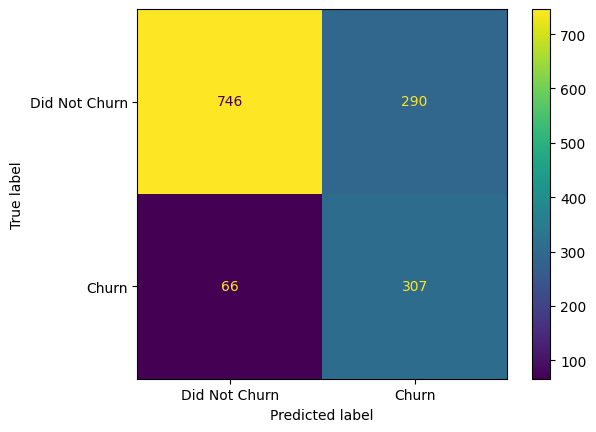

In [97]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Churn', 'Churn'])
disp.plot()
plt.show()

In [98]:
print("\n--- Classification Report ---")
print(classification_report(y_test, predictions, target_names=['Did Not Churn', 'Churn']))


--- Classification Report ---
               precision    recall  f1-score   support

Did Not Churn       0.92      0.72      0.81      1036
        Churn       0.51      0.82      0.63       373

     accuracy                           0.75      1409
    macro avg       0.72      0.77      0.72      1409
 weighted avg       0.81      0.75      0.76      1409



In [100]:
import shap

In [101]:
explainer = shap.Explainer(model, X_train_scaled)

In [102]:
shap_values = explainer(X_test_scaled)

In [103]:
print("--- SHAP Summary Plot ---")
print("This plot shows the most important features that push the model toward predicting 'Churn'.\n")

--- SHAP Summary Plot ---
This plot shows the most important features that push the model toward predicting 'Churn'.



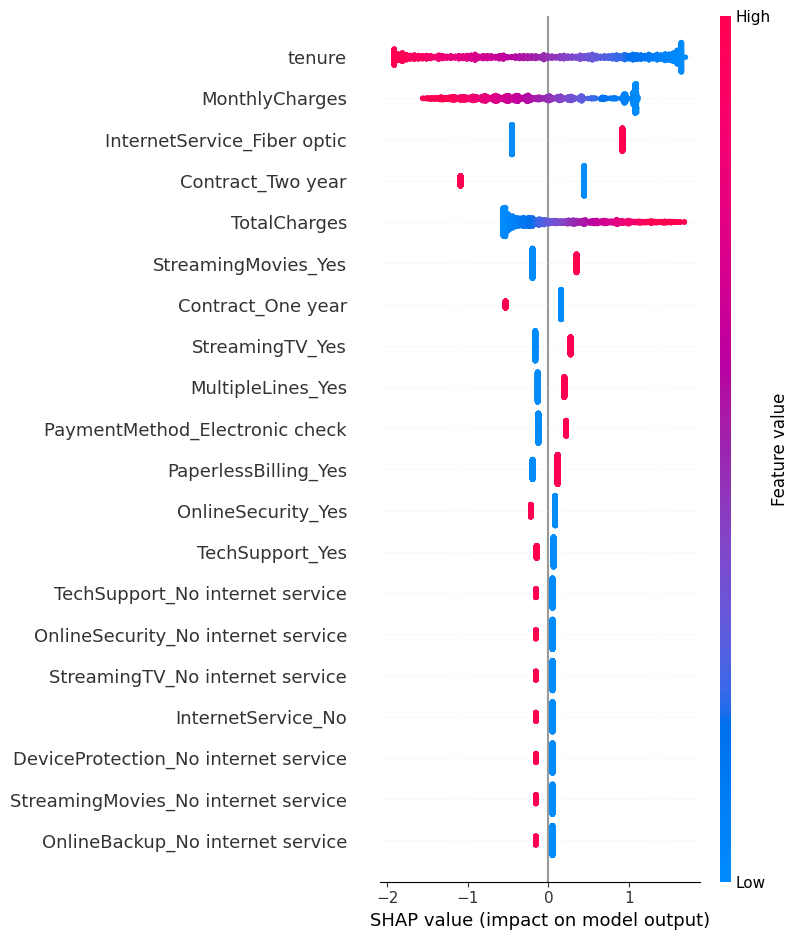

In [105]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)